In [4]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")


# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv(r'C:\Users\FA23-BCS-041.CUI\Desktop\datasets\bank-additional-full.csv', sep=";")

print(df.head())
print(df.info())


   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

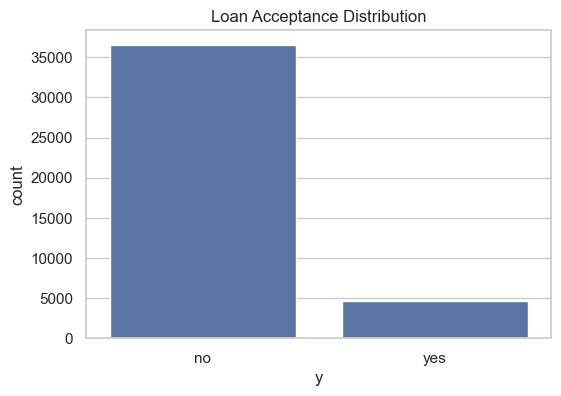

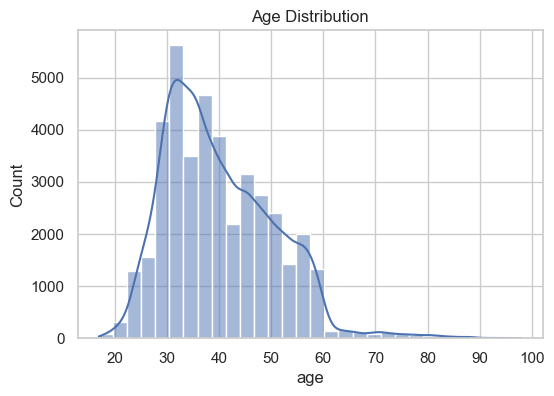

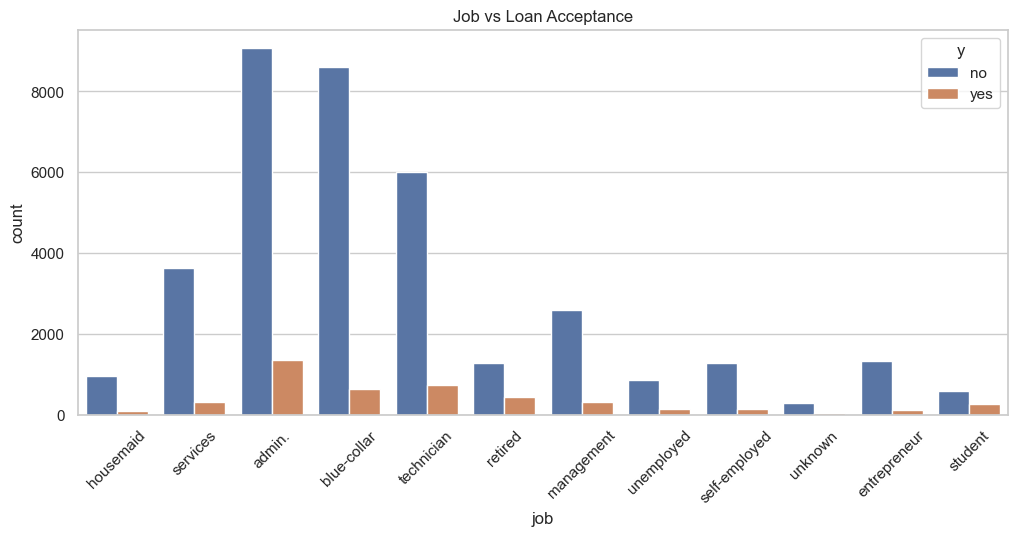

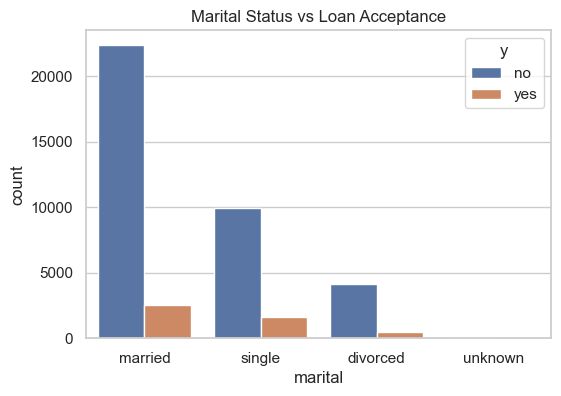

In [5]:
# =========================
# 3. Basic Exploration
# =========================

plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Loan Acceptance Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title("Job vs Loan Acceptance")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='marital', hue='y', data=df)
plt.title("Marital Status vs Loan Acceptance")
plt.show()


# =========================
# 4. Data Preprocessing
# =========================

# Convert target variable
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# One-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

In [9]:
# =========================
# 5. Split Data
# =========================
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# 6. Feature Scaling (IMPORTANT FIX)
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================
# 7. Train Models
# =========================

# Logistic Regression (BEST for this task)
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_scaled, y_train)

# Decision Tree (comparison)
dt_model = DecisionTreeClassifier(max_depth=5)
dt_model.fit(X_train, y_train)


# =========================
# 8. Predictions
# =========================
lr_pred = lr_model.predict(X_test_scaled)
dt_pred = dt_model.predict(X_test)


In [8]:
# =========================
# 9. Evaluation
# =========================

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))


# =========================
# 10. Business Insights (VERY IMPORTANT)
# =========================

print("\nJob-wise Acceptance Rate:")
print(df.groupby("job")["y"].mean().sort_values(ascending=False))

print("\nMarital Status Acceptance Rate:")
print(df.groupby("marital")["y"].mean())

df['age_group'] = pd.cut(df['age'], bins=[18,30,40,50,60,100])

print("\nAge Group Acceptance Rate:")
print(df.groupby("age_group")["y"].mean())


=== Logistic Regression ===
Accuracy: 0.9115076474872542
[[7103  200]
 [ 529  406]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.43      0.53       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238


=== Decision Tree ===
Accuracy: 0.9150279193979121
[[7031  272]
 [ 428  507]]
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7303
           1       0.65      0.54      0.59       935

    accuracy                           0.92      8238
   macro avg       0.80      0.75      0.77      8238
weighted avg       0.91      0.92      0.91      8238


Job-wise Acceptance Rate:
job
student          0.314286
retired          0.252326
unemployed       0.142012
admin.           0.129726
management       0.112175
unknown          0.11